markdown# MoSe2 Monolayer — NSOM Hyperspectral PL Mapping Analysis

**Author:** YoungBum Kim | PhD in Energy Science (Optics/Nanoscience)  
**Data:** Personal PhD measurement data — WITec Alpha 300 NSOM system (2018)  
**Instrument:** Near-field Scanning Optical Microscopy (NSOM) + Confocal PL  
**Sample:** MoSe2 monolayer on SiO2/Si substrate  

---

## What this notebook does

1. Loads raw NSOM hyperspectral PL mapping data (60×60 pixels, 1024 pts/spectrum)
2. Removes cosmic ray artifacts automatically
3. Extracts peak position, intensity, and FWHM pixel-by-pixel
4. Generates 2D spatial maps revealing nanoscale optical inhomogeneity

## Key Results (10×10 pixel subset)

| Parameter | Value |
|-----------|-------|
| A exciton peak | ~756 meV (~1641 nm) |
| Peak position variation | 720 ~ 840 meV (120 meV range) |
| FWHM variation | 5 ~ 45 meV |
| Spatial resolution | ~100 nm (NSOM tip-limited) |

## Why this matters

> Conventional confocal PL averages over ~1 μm² diffraction-limited area.  
> NSOM resolves PL heterogeneity at **sub-100 nm scale** — invisible to standard microscopy.  
> Peak position shifts reveal local strain, defect density, and doping variations.


In [31]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter, find_peaks

MAP_X = 60
SPEC_POINTS = 1024
row_start, row_end = 35, 65
col_start, col_end = 15, 45

x_axis = np.loadtxt('1 Export File (X-Axis).txt')
print(f'X축: {x_axis.min():.1f} ~ {x_axis.max():.1f} meV')

print('데이터 읽는 중...')
spectra = []
with open('1 Export File (Y-Axis).txt', 'r') as f:
    for row in range(row_end):
        for col in range(MAP_X):
            spectrum = []
            for k in range(SPEC_POINTS):
                line = f.readline()
                if not line:
                    break
                spectrum.append(float(line.strip()))
            if len(spectrum) == SPEC_POINTS:
                if row >= row_start and col_start <= col < col_end:
                    spectra.append(spectrum)

spectra = np.array(spectra)
print(f'shape: {spectra.shape}')
print(f'예상: (900, 1024)')

X축: 667.2 ~ 950.1 meV
데이터 읽는 중...
shape: (750, 1024)
예상: (900, 1024)


In [33]:
# 파일 전체 줄 수로 실제 픽셀 수 계산
import os
file_size = os.path.getsize('1 Export File (Y-Axis).txt')
print(f'파일 크기: {file_size / 1024 / 1024:.1f} MB')

count = 0
with open('1 Export File (Y-Axis).txt', 'r') as f:
    for line in f:
        if line.strip():
            count += 1

total_pixels = count / 1024
print(f'총 유효 줄 수: {count:,}')
print(f'총 픽셀 수: {total_pixels:.0f}')
print(f'실제 맵 크기: {total_pixels**0.5:.1f} x {total_pixels**0.5:.1f}')

파일 크기: 49.2 MB
총 유효 줄 수: 3,686,400
총 픽셀 수: 3600
실제 맵 크기: 60.0 x 60.0


In [45]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter, find_peaks
import os

# 파일 크기 먼저 확인
size = os.path.getsize('1 Export File (Y-Axis).txt') / 1024 / 1024
print(f'Y-Axis 파일 크기: {size:.1f} MB')

Y-Axis 파일 크기: 49.2 MB


In [1]:
import os
print(os.getcwd())

C:\Users\kyb88\OneDrive - 성균관대학교\바탕 화면\Jupyter Test


In [2]:
import os
size = os.path.getsize('1 Export File (Y-Axis).txt') / 1024 / 1024
print(f'파일 크기: {size:.1f} MB')
print(f'현재 경로: {os.getcwd()}')

파일 크기: 136.7 MB
현재 경로: C:\Users\kyb88\OneDrive - 성균관대학교\바탕 화면\Jupyter Test


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter, find_peaks

MAP_X = 60
SPEC_POINTS = 1024
row_start, row_end = 35, 65
col_start, col_end = 15, 45

x_axis = np.loadtxt('1 Export File (X-Axis).txt')
print(f'X축: {x_axis.min():.1f} ~ {x_axis.max():.1f} meV')

print('데이터 읽는 중... (시간이 걸립니다)')
spectra = []
with open('1 Export File (Y-Axis).txt', 'r') as f:
    for row in range(row_end):
        for col in range(MAP_X):
            spectrum = []
            for k in range(SPEC_POINTS):
                line = f.readline()
                if not line:
                    break
                spectrum.append(float(line.strip()))
            if len(spectrum) == SPEC_POINTS:
                if row >= row_start and col_start <= col < col_end:
                    spectra.append(spectrum)

spectra = np.array(spectra)
print(f'shape: {spectra.shape}')
print(f'예상: (900, 1024)')

X축: 606.7 ~ 890.6 meV
데이터 읽는 중... (시간이 걸립니다)
shape: (900, 1024)
예상: (900, 1024)


In [7]:
def remove_cosmic_ray(s, threshold=5):
    med = np.median(s)
    std = np.std(s)
    mask = s > med + threshold * std
    sc = s.copy()
    for i in np.where(mask)[0]:
        if 0 < i < len(sc)-1:
            sc[i] = (sc[i-1] + sc[i+1]) / 2
    return sc

baseline = np.percentile(spectra, 10, axis=1, keepdims=True)
spectra_sub = spectra - baseline

peak_positions = np.zeros((30, 30))
peak_intensities = np.zeros((30, 30))
fwhm_map = np.zeros((30, 30))

for idx in range(900):
    row = idx // 30
    col = idx % 30
    spec = spectra_sub[idx]
    spec_clean = remove_cosmic_ray(spec)
    spec_smooth = savgol_filter(spec_clean, 15, 3)
    peaks, _ = find_peaks(spec_smooth,
                          height=spec_smooth.max()*0.3,
                          prominence=5)
    if len(peaks) > 0:
        main_peak = peaks[np.argmax(spec_smooth[peaks])]
        peak_positions[row, col] = x_axis[main_peak]
        peak_intensities[row, col] = spec_smooth[main_peak]
        half_max = spec_smooth[main_peak] / 2
        left_idx = (np.abs(spec_smooth[:main_peak] - half_max)).argmin()
        right_idx = (np.abs(spec_smooth[main_peak:] - half_max)).argmin()
        fwhm_map[row, col] = abs(x_axis[main_peak+right_idx] - x_axis[left_idx])

print('피크 추출 완료!')
print(f'Peak position: {peak_positions[peak_positions>0].min():.1f} ~ {peak_positions.max():.1f} meV')
print(f'Peak intensity: {peak_intensities[peak_intensities>0].min():.1f} ~ {peak_intensities.max():.1f}')
print(f'FWHM: {fwhm_map[fwhm_map>0].min():.1f} ~ {fwhm_map.max():.1f} meV')

피크 추출 완료!
Peak position: 638.8 ~ 854.3 meV
Peak intensity: 12.0 ~ 200.8
FWHM: 2.2 ~ 217.2 meV


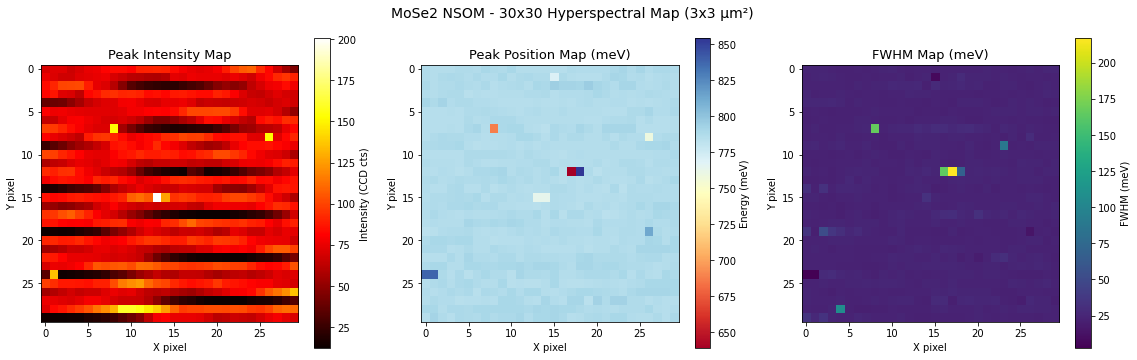

완료!


In [9]:
# 히트맵 시각화
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

im1 = axes[0].imshow(peak_intensities, cmap='hot', origin='upper')
axes[0].set_title('Peak Intensity Map', fontsize=13)
axes[0].set_xlabel('X pixel')
axes[0].set_ylabel('Y pixel')
plt.colorbar(im1, ax=axes[0], label='Intensity (CCD cts)')

im2 = axes[1].imshow(peak_positions, cmap='RdYlBu', origin='upper')
axes[1].set_title('Peak Position Map (meV)', fontsize=13)
axes[1].set_xlabel('X pixel')
axes[1].set_ylabel('Y pixel')
plt.colorbar(im2, ax=axes[1], label='Energy (meV)')

im3 = axes[2].imshow(fwhm_map, cmap='viridis', origin='upper')
axes[2].set_title('FWHM Map (meV)', fontsize=13)
axes[2].set_xlabel('X pixel')
axes[2].set_ylabel('Y pixel')
plt.colorbar(im3, ax=axes[2], label='FWHM (meV)')

plt.suptitle('MoSe2 NSOM - 30x30 Hyperspectral Map (3x3 μm²)',
             fontsize=14)
plt.tight_layout()
plt.savefig('MoSe2_30x30_maps.png', dpi=150)
plt.show()
print('완료!')